In [1]:
!pip install plotly


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print("✅ All libraries imported successfully!")



✅ All libraries imported successfully!


In [11]:
#── OPTION B: Mount Google Drive (comment out Option A above first) ──
from google.colab import drive
drive.mount('/content/drive')
group_df = pd.read_csv('/content/drive/MyDrive/PythonProject/cleaned_group_death_claims.csv')
indiv_df = pd.read_csv('/content/drive/MyDrive/PythonProject/cleaned_individual_death_claims.csv')

print(f"\n✅ Group claims loaded: {group_df.shape[0]} rows × {group_df.shape[1]} columns")
print(f"✅ Individual claims loaded: {indiv_df.shape[0]} rows × {indiv_df.shape[1]} columns")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Group claims loaded: 149 rows × 25 columns
✅ Individual claims loaded: 149 rows × 25 columns


In [9]:
print("=" * 45)
print("INDIVIDUAL DEATH CLAIMS — First 3 rows")
print("=" * 45)
indiv_df.head(3)

INDIVIDUAL DEATH CLAIMS — First 3 rows


,life_insurer,year,claims_pending_start_no,claims_pending_start_amt,claims_intimated_no,claims_intimated_amt,total_claims_no,total_claims_amt,claims_paid_no,claims_paid_amt,...,claims_unclaimed_amt,claims_pending_end_no,claims_pending_end_amt,claims_paid_ratio_no,claims_paid_ratio_amt,claims_repudiated_rejected_ratio_no,claims_repudiated_rejected_ratio_amt,claims_pending_ratio_no,claims_pending_ratio_amt,category
0,ABSL,2021-22,11,3.637908,9997,876.685045,10008,880.322952,9815,846.434314,...,0.0,7,0.907645,0.980715,0.961504,0.018585,0.037465,0.000699,0.001031,Individual Death Claims
1,Aegon,2021-22,0,0.000000,720,276.480000,720,276.480000,713,273.040000,...,0.0,1,0.020000,0.990278,0.987558,0.008333,0.012370,0.001389,0.000072,Individual Death Claims
2,Ageas,2021-22,50,6.698502,2644,128.032758,2694,134.731259,2614,122.629249,...,0.0,23,3.432473,0.970304,0.910177,0.021158,0.064347,0.008537,0.025476,Individual Death Claims


In [10]:
print("=" * 45)
print("GROUP DEATH CLAIMS — First 3 rows")
print("=" * 45)
group_df.head(3)

GROUP DEATH CLAIMS — First 3 rows


,life_insurer,year,claims_pending_start_no,claims_pending_start_amt,claims_intimated_no,claims_intimated_amt,total_claims_no,total_claims_amt,claims_paid_no,claims_paid_amt,...,claims_unclaimed_amt,claims_pending_end_no,claims_pending_end_amt,claims_paid_ratio_no,claims_paid_ratio_amt,claims_repudiated_rejected_ratio_no,claims_repudiated_rejected_ratio_amt,claims_pending_ratio_no,claims_pending_ratio_amt,category
0,ABSL,2021-22,7,1.694481,13518,675.255903,13525,676.950384,13470,666.773292,...,0.0,3,2.394170,0.995933,0.984966,0.003845,0.011497,0.000222,0.003537,Group Death Claims
1,Aegon,2021-22,0,0.000000,361,76.060000,361,76.060000,361,76.030000,...,0.0,0,0.030000,1.000000,0.999606,0.000000,0.000000,0.000000,0.000394,Group Death Claims
2,Ageas,2021-22,15,4.806674,481,100.826625,496,105.633299,446,89.031366,...,0.0,5,1.420366,0.899194,0.842834,0.090726,0.143720,0.010081,0.013446,Group Death Claims


In [6]:
print("""
📋 COLUMN GLOSSARY
──────────────────────────────────────────────────────
life_insurer               : Name of the insurance company
year                       : Financial year (e.g. 2021-22)
claims_pending_start_no/amt: Claims pending at start of year (count / ₹ Crore)
claims_intimated_no/amt    : New claims received during the year
total_claims_no/amt        : Pending start + Intimated
claims_paid_no/amt         : Claims successfully paid out
claims_repudiated_no/amt   : Claims rejected after investigation
claims_rejected_no/amt     : Claims rejected upfront
claims_unclaimed_no/amt    : Claims not collected by beneficiary
claims_pending_end_no/amt  : Claims still open at year end
claims_paid_ratio_no/amt   : % of claims paid (by count / by amount)
claims_repudiated_..._ratio: % repudiated+rejected
claims_pending_ratio       : % still pending
category                   : 'Group Death Claims' or 'Individual Death Claims'
""")


📋 COLUMN GLOSSARY
──────────────────────────────────────────────────────
life_insurer               : Name of the insurance company
year                       : Financial year (e.g. 2021-22)
claims_pending_start_no/amt: Claims pending at start of year (count / ₹ Crore)
claims_intimated_no/amt    : New claims received during the year
total_claims_no/amt        : Pending start + Intimated
claims_paid_no/amt         : Claims successfully paid out
claims_repudiated_no/amt   : Claims rejected after investigation
claims_rejected_no/amt     : Claims rejected upfront
claims_unclaimed_no/amt    : Claims not collected by beneficiary
claims_pending_end_no/amt  : Claims still open at year end
claims_paid_ratio_no/amt   : % of claims paid (by count / by amount)
claims_repudiated_..._ratio: % repudiated+rejected
claims_pending_ratio       : % still pending
category                   : 'Group Death Claims' or 'Individual Death Claims'



In [14]:
# Combine both datasets for joint analysis
combined_df = pd.concat([group_df, indiv_df], ignore_index=True)

print("COMBINED DATASET SHAPE:", combined_df.shape)
print()
print("Missing values per column:")
missing = combined_df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values!")
print()
print("Data types:")
print(combined_df.dtypes)
combined_df.tail(10)

COMBINED DATASET SHAPE: (298, 25)

Missing values per column:
claims_pending_ratio_amt    1
dtype: int64

Data types:
life_insurer                             object
year                                     object
claims_pending_start_no                   int64
claims_pending_start_amt                float64
claims_intimated_no                       int64
claims_intimated_amt                    float64
total_claims_no                           int64
total_claims_amt                        float64
claims_paid_no                            int64
claims_paid_amt                         float64
claims_repudiated_no                      int64
claims_repudiated_amt                   float64
claims_rejected_no                        int64
claims_rejected_amt                     float64
claims_unclaimed_no                       int64
claims_unclaimed_amt                    float64
claims_pending_end_no                     int64
claims_pending_end_amt                  float64
claims_paid_ratio_

,life_insurer,year,claims_pending_start_no,claims_pending_start_amt,claims_intimated_no,claims_intimated_amt,total_claims_no,total_claims_amt,claims_paid_no,claims_paid_amt,...,claims_unclaimed_amt,claims_pending_end_no,claims_pending_end_amt,claims_paid_ratio_no,claims_paid_ratio_amt,claims_repudiated_rejected_ratio_no,claims_repudiated_rejected_ratio_amt,claims_pending_ratio_no,claims_pending_ratio_amt,category
288,Max Life,2017-18,3,0.146875,10329,370.848036,10332,370.994912,10152,353.393597,...,1.017865,3,1.596255e+00,0.982578,0.952556,0.017228,0.044700,0.000290,4.302634e-03,Individual Death Claims
289,PNB Met Life,2017-18,108,16.428039,3981,201.537802,4089,217.965842,3726,179.602010,...,4.107871,0,1.186759e-13,0.911225,0.823992,0.086818,0.157162,0.000000,5.444702e-16,Individual Death Claims
290,Pramerica Life,2017-18,6,0.696429,586,25.814493,592,26.510922,572,23.508784,...,1.708052,2,2.980006e-01,0.966216,0.886758,0.021959,0.048813,0.003378,1.124067e-02,Individual Death Claims
291,Private Total,2017-18,942,112.750862,107962,4221.237920,108904,4333.988781,103718,3876.288264,...,103.097264,226,5.590266e+01,0.952380,0.894393,0.041330,0.081819,0.002075,1.289866e-02,Individual Death Claims
292,Reliance Nippon,2017-18,35,4.755961,8952,168.906509,8987,173.662470,8553,149.536253,...,1.097379,4,9.064091e-01,0.951708,0.861074,0.047847,0.132607,0.000445,5.219372e-03,Individual Death Claims
293,SBI Life,2017-18,132,25.192603,18753,615.588585,18885,640.781187,18274,590.327167,...,5.633757,28,4.634057e+00,0.967646,0.921262,0.028541,0.069946,0.001483,7.231887e-03,Individual Death Claims
294,Sahara Life,2017-18,26,0.376146,646,6.242128,672,6.618274,556,5.405455,...,0.478456,16,2.368000e-01,0.000000,0.000000,0.000000,0.000000,0.000000,3.577972e-02,Individual Death Claims
295,Shriram,2017-18,293,14.280158,2853,87.471935,3146,101.752093,2524,69.799383,...,5.059487,39,2.156832e+00,0.802289,0.685975,0.178004,0.264301,0.012397,2.119693e-02,Individual Death Claims
296,Star Union,2017-18,19,2.697453,1222,49.594740,1241,52.292193,1145,43.420676,...,2.130000,5,3.303994e-01,0.922643,0.830347,0.067687,0.128920,0.004029,6.318331e-03,Individual Death Claims
297,Tata AIA,2017-18,0,0.000000,2850,140.254515,2850,140.254515,2793,131.843542,...,0.004394,0,-6.217249e-15,0.980000,0.940031,0.020000,0.059938,0.000000,-4.432833e-17,Individual Death Claims


In [15]:
# Fill the single missing value in 'claims_pending_ratio_amt' with the median
median_value = combined_df['claims_pending_ratio_amt'].median()
combined_df['claims_pending_ratio_amt'] = combined_df['claims_pending_ratio_amt'].fillna(median_value)

print("Missing values after imputation:")
missing_after_imputation = combined_df.isnull().sum()
print(missing_after_imputation[missing_after_imputation > 0] if missing_after_imputation.sum() > 0 else "✅ No missing values after imputation!")

Missing values after imputation:
✅ No missing values after imputation!


In [16]:
# Convert 'year' to a consistent format (e.g., just the start year of the financial year)
combined_df['year_start'] = combined_df['year'].apply(lambda x: int(x.split('-')[0]))

# Drop the original 'year' column as 'year_start' is more useful for numerical analysis
combined_df = combined_df.drop(columns=['year'])

print("Unique values in new 'year_start' column:", combined_df['year_start'].unique())

Unique values in new 'year_start' column: [2021 2020 2019 2018 2017]


In [17]:
# Filter out aggregate rows for insurer-level analysis
exclude_labels = ['Industry Total', 'Private Total', 'Industry', 'PVT.']

group_ins  = group_df[~group_df['life_insurer'].isin(exclude_labels)].copy()
indiv_ins  = indiv_df[~indiv_df['life_insurer'].isin(exclude_labels)].copy()

# Standardise duplicate insurer names
name_map = {
    'ABSL': 'Aditya Birla Life', 'Baj Alz': 'Bajaj Allianz',
    'Can HSBC': 'Canara HSBC OBC', 'Edelws': 'Edelweiss Tokio',
    'Exide': 'Exide Life', 'Fut Genli': 'Future Generali',
    'HDFC': 'HDFC Life', 'ICICI': 'ICICI Prudential',
    'Indiafirst': 'India First', 'Kotak': 'Kotak Mahindra',
    'PNB Met Life': 'PNB Metlife', 'Ageas': 'Ageas Federal',
    'Reliance': 'Reliance Nippon'
}
for df_ in [group_ins, indiv_ins]:
    df_['life_insurer'] = df_['life_insurer'].replace(name_map)

print("✅ Cleaned insurer names. Unique insurers:", group_ins['life_insurer'].nunique())

✅ Cleaned insurer names. Unique insurers: 28


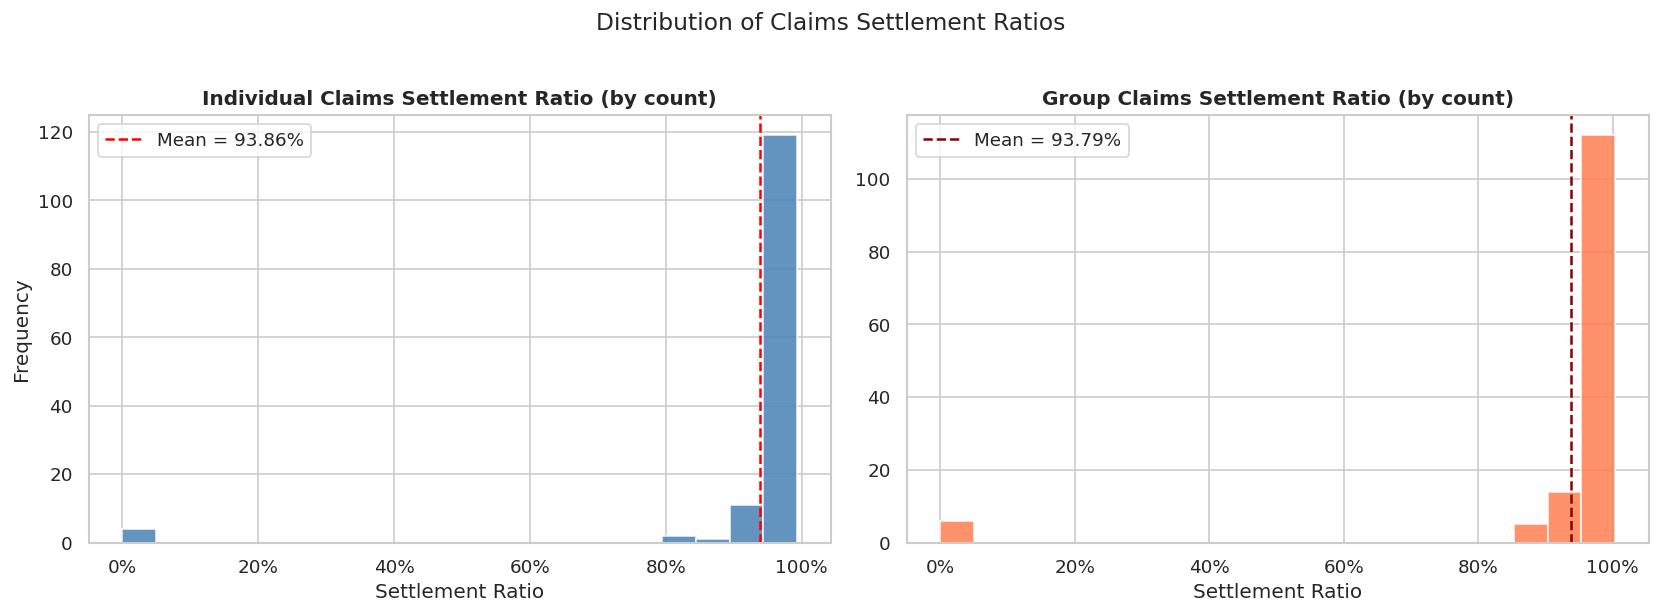

💡 Insight: Most insurers settle >95% of claims. Group policies show slightly wider variance.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Claims paid ratio — Individual
axes[0].hist(indiv_ins['claims_paid_ratio_no'], bins=20,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(indiv_ins['claims_paid_ratio_no'].mean(),
                color='red', linestyle='--', label=f"Mean = {indiv_ins['claims_paid_ratio_no'].mean():.2%}")
axes[0].set_title('Individual Claims Settlement Ratio (by count)', fontweight='bold')
axes[0].set_xlabel('Settlement Ratio')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend()

# Claims paid ratio — Group
axes[1].hist(group_ins['claims_paid_ratio_no'], bins=20,
             color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(group_ins['claims_paid_ratio_no'].mean(),
                color='darkred', linestyle='--', label=f"Mean = {group_ins['claims_paid_ratio_no'].mean():.2%}")
axes[1].set_title('Group Claims Settlement Ratio (by count)', fontweight='bold')
axes[1].set_xlabel('Settlement Ratio')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend()

plt.suptitle('Distribution of Claims Settlement Ratios', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_01_distribution.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Most insurers settle >95% of claims. Group policies show slightly wider variance.")

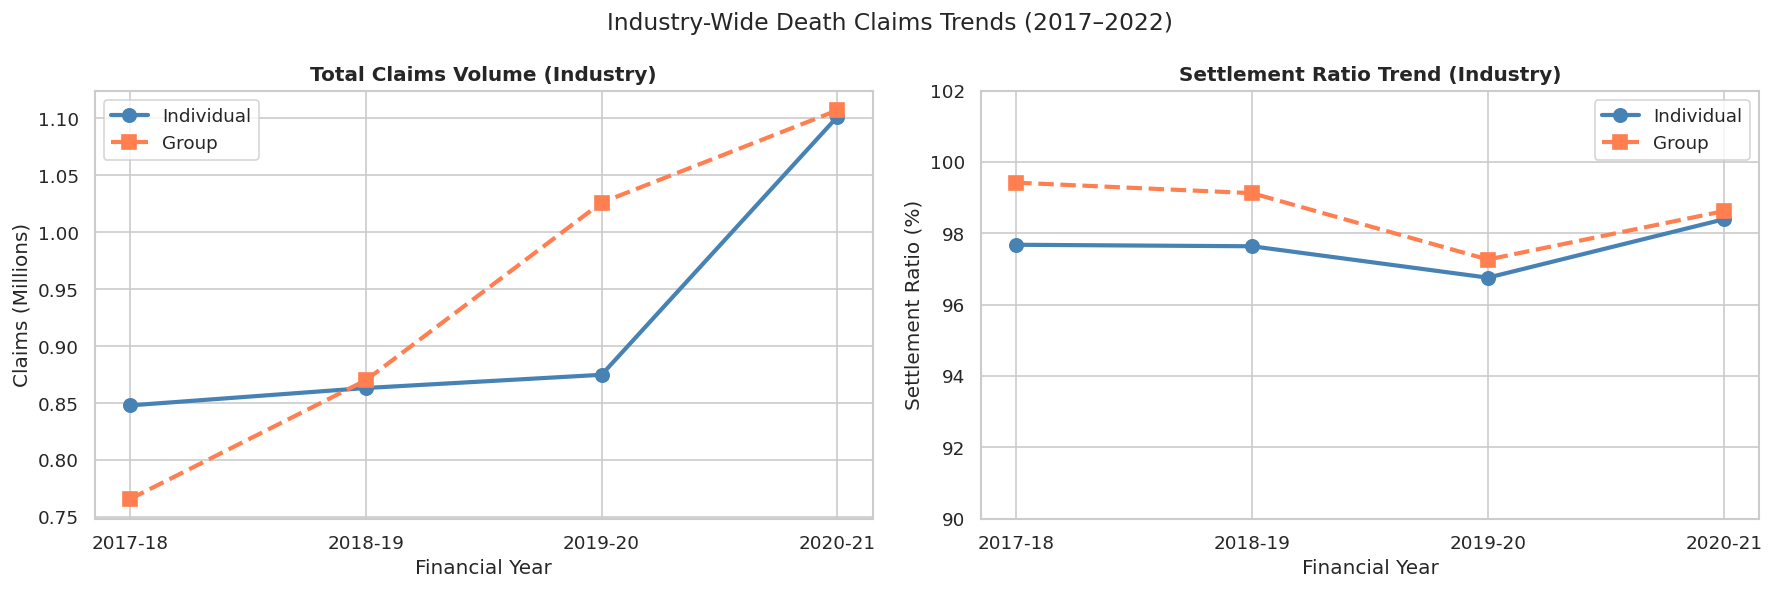

💡 Insight: Claims volume surged in 2020-21 (COVID-19 impact). Settlement ratios dipped slightly during this stress period.


In [19]:
# Use aggregate rows for industry trend
industry_g = group_df[group_df['life_insurer'] == 'Industry Total'].sort_values('year')
industry_i = indiv_df[indiv_df['life_insurer'] == 'Industry Total'].sort_values('year')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

years = industry_i['year'].tolist()

# Total claims volume
axes[0].plot(years, industry_i['total_claims_no'] / 1e6, 'o-', color='steelblue',
             linewidth=2.5, markersize=8, label='Individual')
axes[0].plot(years, industry_g['total_claims_no'] / 1e6, 's--', color='coral',
             linewidth=2.5, markersize=8, label='Group')
axes[0].set_title('Total Claims Volume (Industry)', fontweight='bold')
axes[0].set_ylabel('Claims (Millions)')
axes[0].legend()
axes[0].set_xlabel('Financial Year')

# Settlement ratio trend
axes[1].plot(years, industry_i['claims_paid_ratio_no'] * 100, 'o-', color='steelblue',
             linewidth=2.5, markersize=8, label='Individual')
axes[1].plot(years, industry_g['claims_paid_ratio_no'] * 100, 's--', color='coral',
             linewidth=2.5, markersize=8, label='Group')
axes[1].set_title('Settlement Ratio Trend (Industry)', fontweight='bold')
axes[1].set_ylabel('Settlement Ratio (%)')
axes[1].set_ylim(90, 102)
axes[1].legend()
axes[1].set_xlabel('Financial Year')

plt.suptitle('Industry-Wide Death Claims Trends (2017–2022)', fontsize=14)
plt.tight_layout()
plt.savefig('plot_02_industry_trend.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Claims volume surged in 2020-21 (COVID-19 impact). Settlement ratios dipped slightly during this stress period.")

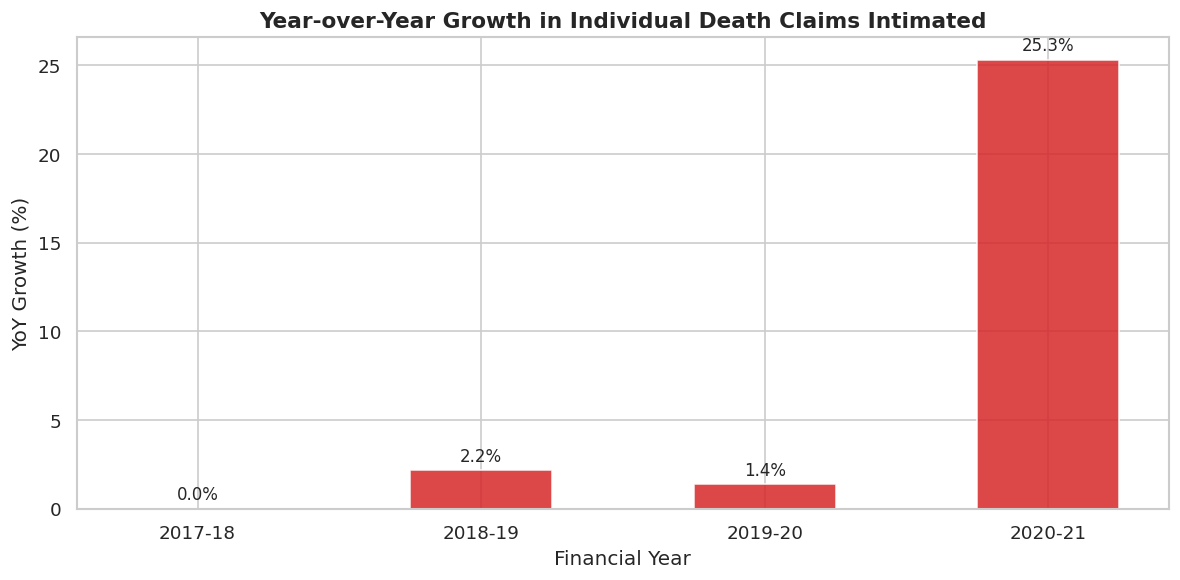

💡 Insight: 2020-21 saw a dramatic spike in death claims — directly linked to COVID-19 pandemic mortality.


In [20]:
# YoY growth in claims intimated
industry_i_sorted = indiv_df[indiv_df['life_insurer'] == 'Industry Total'].sort_values('year').reset_index(drop=True)
industry_i_sorted['yoy_growth'] = industry_i_sorted['claims_intimated_no'].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if y > 0 else '#2ca02c' for y in industry_i_sorted['yoy_growth'].fillna(0)]
bars = ax.bar(industry_i_sorted['year'], industry_i_sorted['yoy_growth'].fillna(0),
              color=colors, alpha=0.85, edgecolor='white', width=0.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Year-over-Year Growth in Individual Death Claims Intimated', fontweight='bold', fontsize=13)
ax.set_ylabel('YoY Growth (%)')
ax.set_xlabel('Financial Year')
for bar, val in zip(bars, industry_i_sorted['yoy_growth'].fillna(0)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('plot_03_covid_impact.png', bbox_inches='tight')
plt.show()
print("💡 Insight: 2020-21 saw a dramatic spike in death claims — directly linked to COVID-19 pandemic mortality.")

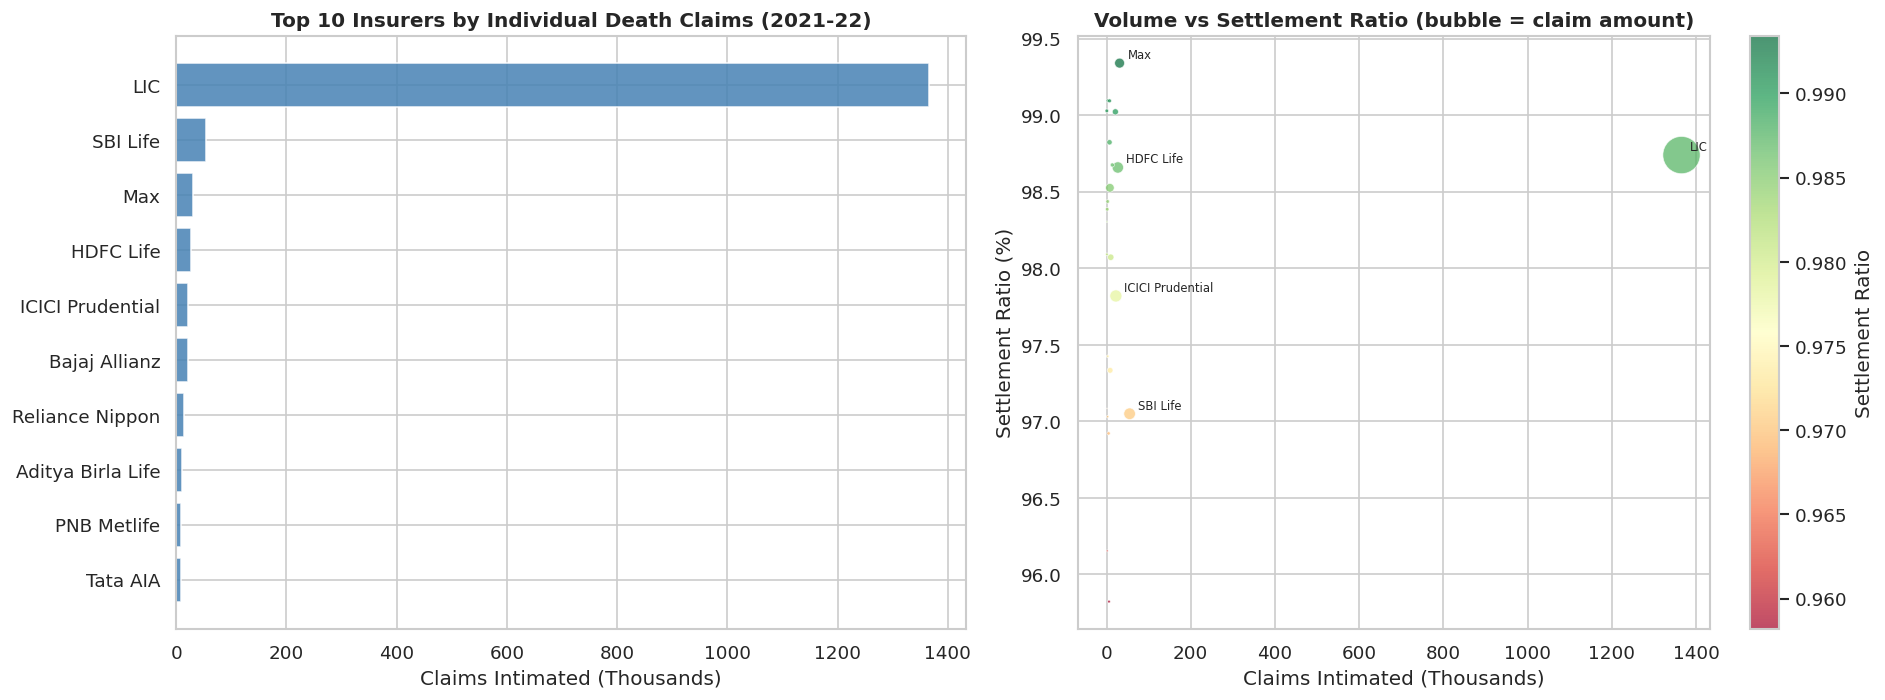

In [21]:
# Get latest year data for individual insurers
latest_indiv = indiv_ins[indiv_ins['year'] == '2021-22'].copy()
latest_group = group_ins[group_ins['year'] == '2021-22'].copy()

# Top 10 by claims volume (Individual)
top10_indiv = latest_indiv.nlargest(10, 'claims_intimated_no')[
    ['life_insurer', 'claims_intimated_no', 'claims_paid_ratio_no', 'claims_repudiated_rejected_ratio_no']
].sort_values('claims_intimated_no')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar — volume
axes[0].barh(top10_indiv['life_insurer'], top10_indiv['claims_intimated_no'] / 1000,
             color='steelblue', alpha=0.85)
axes[0].set_title('Top 10 Insurers by Individual Death Claims (2021-22)', fontweight='bold')
axes[0].set_xlabel("Claims Intimated (Thousands)")

# Scatter — volume vs settlement ratio
sc = axes[1].scatter(latest_indiv['claims_intimated_no'] / 1000,
                     latest_indiv['claims_paid_ratio_no'] * 100,
                     s=latest_indiv['claims_paid_amt'] / latest_indiv['claims_paid_amt'].max() * 500,
                     alpha=0.7, c=latest_indiv['claims_paid_ratio_no'],
                     cmap='RdYlGn', edgecolors='white', linewidth=0.5)
plt.colorbar(sc, ax=axes[1], label='Settlement Ratio')
axes[1].set_xlabel('Claims Intimated (Thousands)')
axes[1].set_ylabel('Settlement Ratio (%)')
axes[1].set_title('Volume vs Settlement Ratio (bubble = claim amount)', fontweight='bold')
# Label top few
for _, row in latest_indiv.nlargest(5, 'claims_intimated_no').iterrows():
    axes[1].annotate(row['life_insurer'],
                     (row['claims_intimated_no']/1000, row['claims_paid_ratio_no']*100),
                     textcoords="offset points", xytext=(5, 3), fontsize=7)

plt.tight_layout()
plt.savefig('plot_04_insurer_comparison.png', bbox_inches='tight')
plt.show()

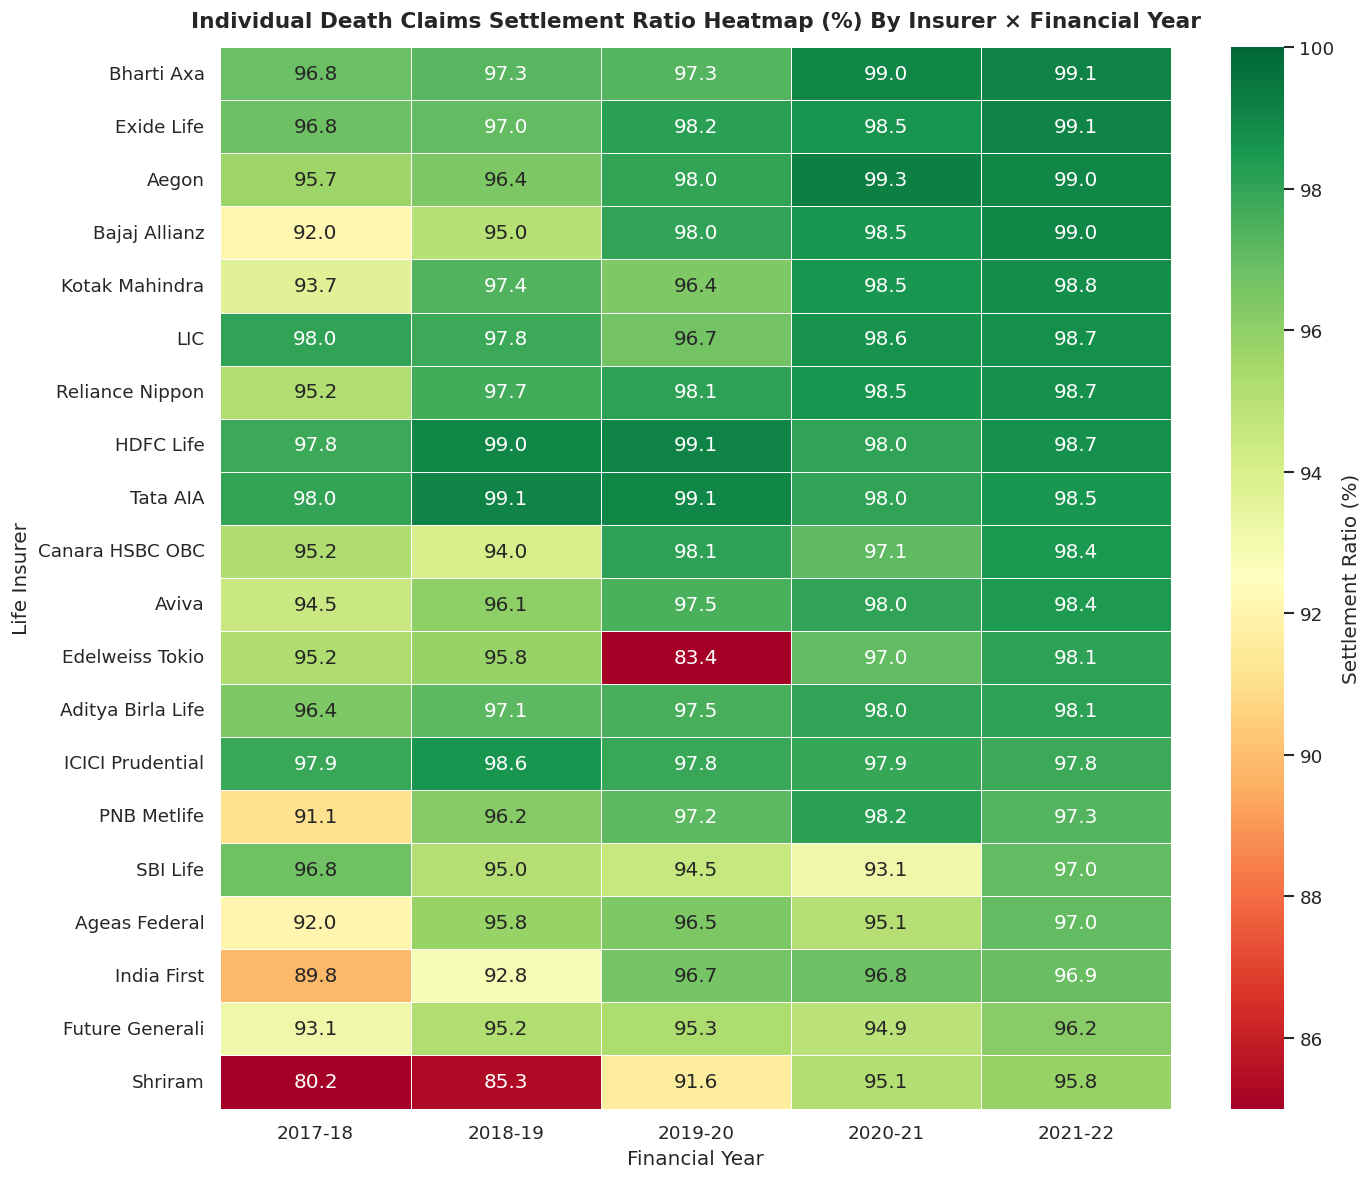

💡 Insight: Red cells reveal stress years (COVID impact in 2020-21) or structurally weaker insurers.


In [24]:
# Pivot: insurers × years
pivot_indiv = indiv_ins.pivot_table(
    index='life_insurer', columns='year',
    values='claims_paid_ratio_no', aggfunc='mean'
) * 100

# Keep only insurers with all 5 years
pivot_indiv = pivot_indiv.dropna()
pivot_indiv = pivot_indiv.sort_values('2021-22', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pivot_indiv, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            vmin=85, vmax=100, ax=ax,
            cbar_kws={'label': 'Settlement Ratio (%)'})
ax.set_title('Individual Death Claims Settlement Ratio Heatmap (%) By Insurer × Financial Year',
             fontweight='bold', fontsize=13, pad=12)
ax.set_xlabel('Financial Year')
ax.set_ylabel('Life Insurer')
plt.tight_layout()
plt.savefig('plot_05_heatmap.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Red cells reveal stress years (COVID impact in 2020-21) or structurally weaker insurers.")

In [25]:
# Compare the two categories across all years
merged = pd.merge(
    group_df[group_df['life_insurer'] == 'Industry Total'][['year','claims_paid_ratio_no','total_claims_no']],
    indiv_df[indiv_df['life_insurer'] == 'Industry Total'][['year','claims_paid_ratio_no','total_claims_no']],
    on='year', suffixes=('_group', '_indiv')
).sort_values('year')

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Settlement Ratio: Group vs Individual',
                                    'Total Claims Volume: Group vs Individual'])

fig.add_trace(go.Scatter(x=merged['year'], y=merged['claims_paid_ratio_no_group']*100,
                         mode='lines+markers', name='Group', line=dict(color='coral', width=3)), row=1, col=1)
fig.add_trace(go.Scatter(x=merged['year'], y=merged['claims_paid_ratio_no_indiv']*100,
                         mode='lines+markers', name='Individual', line=dict(color='steelblue', width=3)), row=1, col=1)

fig.add_trace(go.Bar(x=merged['year'], y=merged['total_claims_no_group'],
                     name='Group Vol', marker_color='coral', opacity=0.8), row=1, col=2)
fig.add_trace(go.Bar(x=merged['year'], y=merged['total_claims_no_indiv'],
                     name='Individual Vol', marker_color='steelblue', opacity=0.8), row=1, col=2)

fig.update_layout(title='Group vs Individual Death Claims — Industry Comparison',
                  barmode='group', height=420, template='plotly_white')
fig.show()

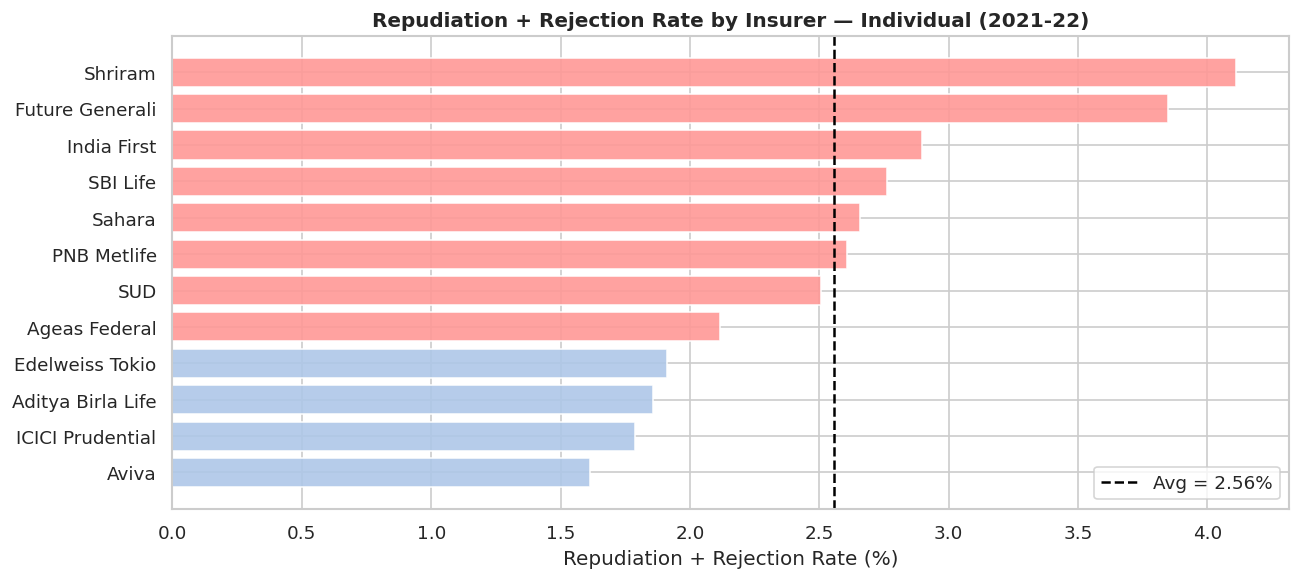

💡 Insight: High repudiation may signal stricter due diligence OR mis-selling. Cross-check with claim volumes.


In [26]:
latest_indiv_rep = indiv_ins[indiv_ins['year'] == '2021-22'].copy()
latest_indiv_rep['rep_rej_pct'] = latest_indiv_rep['claims_repudiated_rejected_ratio_no'] * 100

rep_sorted = latest_indiv_rep.sort_values('rep_rej_pct', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(rep_sorted['life_insurer'][::-1], rep_sorted['rep_rej_pct'][::-1],
               color=['#d62728' if v > 5 else '#ff9896' if v > 2 else '#aec7e8'
                      for v in rep_sorted['rep_rej_pct'][::-1]],
               edgecolor='white', alpha=0.9)
ax.axvline(rep_sorted['rep_rej_pct'].mean(), color='black', linestyle='--',
           label=f'Avg = {rep_sorted["rep_rej_pct"].mean():.2f}%')
ax.set_title('Repudiation + Rejection Rate by Insurer — Individual (2021-22)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Repudiation + Rejection Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_06_repudiation.png', bbox_inches='tight')
plt.show()
print("💡 Insight: High repudiation may signal stricter due diligence OR mis-selling. Cross-check with claim volumes.")

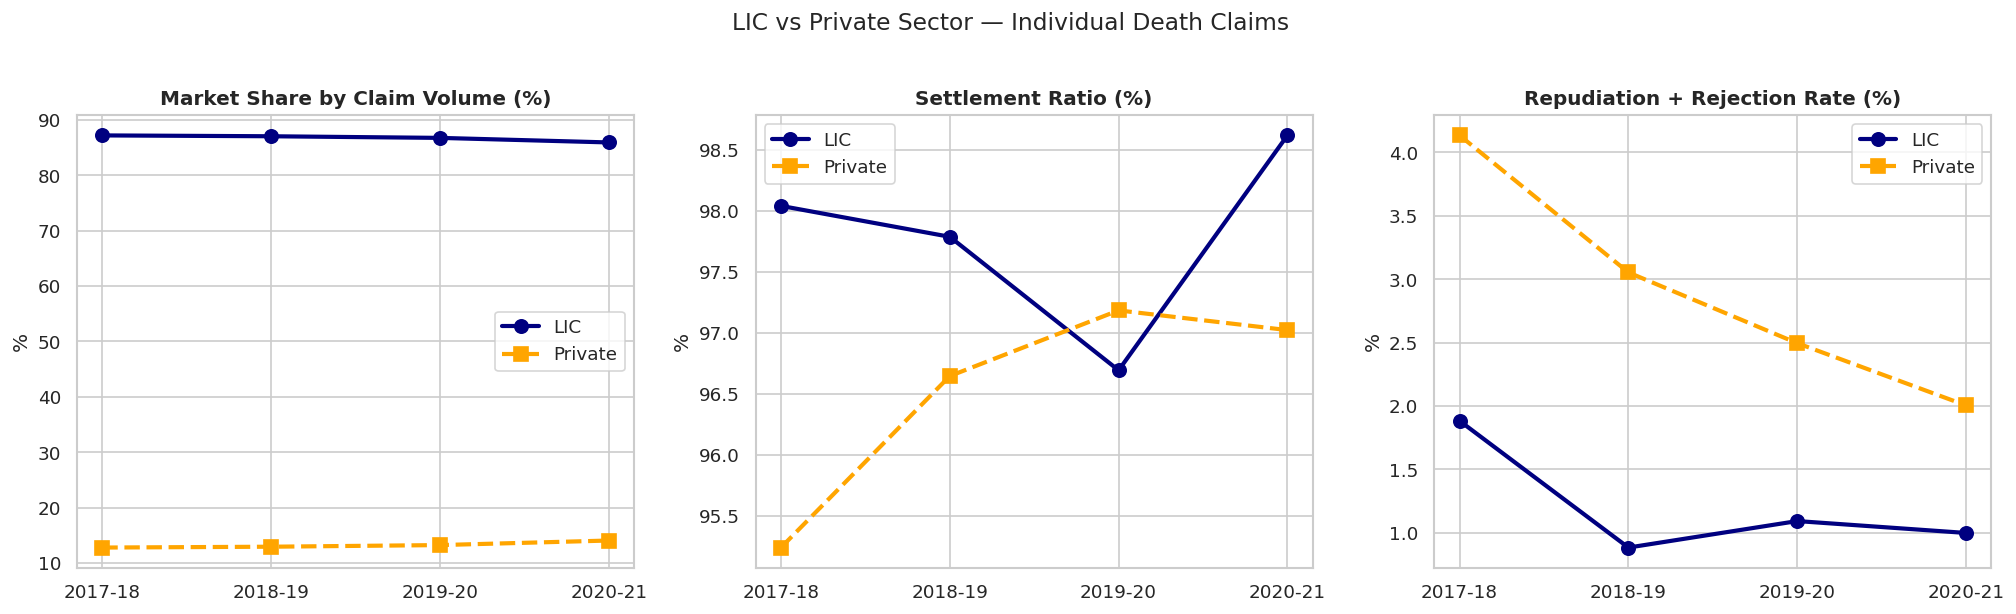

In [30]:
lic_i = indiv_df[indiv_df['life_insurer'] == 'LIC'].sort_values('year')
prv_i = indiv_df[indiv_df['life_insurer'] == 'Private Total'].sort_values('year')
ind_i = indiv_df[indiv_df['life_insurer'] == 'Industry Total'].sort_values('year')

# Determine common years present in ind_i (which has fewer years and acts as denominator)
common_years = ind_i['year'].unique()

# Filter lic_i and prv_i to include only these common years for consistent comparison
lic_i = lic_i[lic_i['year'].isin(common_years)].sort_values('year')
prv_i = prv_i[prv_i['year'].isin(common_years)].sort_values('year')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

years = lic_i['year'].tolist() # Now 'years' will correctly reflect the common 4 years

# Market share by claim volume
axes[0].plot(years, lic_i['claims_intimated_no'] / ind_i['claims_intimated_no'].values * 100,
             'o-', color='navy', lw=2.5, ms=8, label='LIC')
axes[0].plot(years, prv_i['claims_intimated_no'] / ind_i['claims_intimated_no'].values * 100,
             's--', color='orange', lw=2.5, ms=8, label='Private')
axes[0].set_title('Market Share by Claim Volume (%)', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].legend()

# Settlement ratio
axes[1].plot(years, lic_i['claims_paid_ratio_no'] * 100, 'o-', color='navy', lw=2.5, ms=8, label='LIC')
axes[1].plot(years, prv_i['claims_paid_ratio_no'] * 100, 's--', color='orange', lw=2.5, ms=8, label='Private')
axes[1].set_title('Settlement Ratio (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend()

# Repudiation ratio
axes[2].plot(years, lic_i['claims_repudiated_rejected_ratio_no'] * 100,
             'o-', color='navy', lw=2.5, ms=8, label='LIC')
axes[2].plot(years, prv_i['claims_repudiated_rejected_ratio_no'] * 100,
             's--', color='orange', lw=2.5, ms=8, label='Private')
axes[2].set_title('Repudiation + Rejection Rate (%)', fontweight='bold')
axes[2].set_ylabel('%')
axes[2].legend()

plt.suptitle('LIC vs Private Sector — Individual Death Claims', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_07_lic_vs_private.png', bbox_inches='tight')
plt.show()

In [31]:
summary = indiv_ins.groupby('year').agg(
    avg_settlement_ratio=('claims_paid_ratio_no', 'mean'),
    median_settlement_ratio=('claims_paid_ratio_no', 'median'),
    total_claims=('total_claims_no', 'sum'),
    total_paid=('claims_paid_no', 'sum'),
    total_repudiated=('claims_repudiated_no', 'sum'),
    avg_repudiation_rate=('claims_repudiated_rejected_ratio_no', 'mean')
).reset_index()

summary['avg_settlement_ratio'] = summary['avg_settlement_ratio'].map('{:.2%}'.format)
summary['median_settlement_ratio'] = summary['median_settlement_ratio'].map('{:.2%}'.format)
summary['avg_repudiation_rate'] = summary['avg_repudiation_rate'].map('{:.2%}'.format)

print("Individual Death Claims — Industry Summary by Year")
display(summary)

Individual Death Claims — Industry Summary by Year


,year,avg_settlement_ratio,median_settlement_ratio,total_claims,total_paid,total_repudiated,avg_repudiation_rate
0,2017-18,90.56%,95.23%,847986,828314,9286,4.74%
1,2018-19,92.13%,96.60%,863237,842847,6372,3.36%
2,2019-20,92.57%,97.44%,874849,846476,8927,2.92%
3,2020-21,95.13%,98.01%,1209736,1190133,10952,1.88%
4,2021-22,98.04%,98.34%,1608924,1587110,12609,1.78%


In [32]:
import zipfile, os

# Save cleaned combined dataset

combined_clean = pd.concat([

    group_ins.assign(category='Group'),

    indiv_ins.assign(category='Individual')

], ignore_index=True)

combined_clean.to_csv('life_insurance_eda_cleaned.csv', index=False)

# Zip all plots

with zipfile.ZipFile('eda_charts.zip', 'w') as z:

    for f in os.listdir():

        if f.startswith('plot_') and f.endswith('.png'):

            z.write(f)

print("✅ Cleaned data saved: life_insurance_eda_cleaned.csv")

print("✅ Charts zipped: eda_charts.zip")

# Download

from google.colab import files

files.download('life_insurance_eda_cleaned.csv')

files.download('eda_charts.zip')

✅ Cleaned data saved: life_insurance_eda_cleaned.csv
✅ Charts zipped: eda_charts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>